In [1]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

Ce notebook compare la sémantiques utilisé par les trois journaux sélectionnés

In [2]:
with open('figaro.txt') as f:
    data=f.read()
dat=data.replace('Ã©','é').replace('ï¿½','é')
fig = ast.literal_eval(dat) 

In [3]:
with open('le_monde.txt') as f:
    data=f.read()
monde = ast.literal_eval(data) 

In [4]:
with open('libe.txt',encoding='utf-8') as f:
    data=f.read()
libe=ast.literal_eval(data)

In [5]:
x=list(libe.keys())
l=list(monde.keys())
for i,j in enumerate(l):
    monde[x[i]]=monde.pop(j)

In [6]:
x=list(libe.keys())
l=list(fig.keys())
for i,j in enumerate(l):
    fig[x[i]]=fig.pop(j)

In [7]:
def sum(a,b,c=None):
    res=[]
    if c!=None:
        for i,j,k in zip(a,b,c):
            res.append((i[0],i[1]+j[1]+k[1]))
    else:
        for i,j in zip(a,b):
            res.append((i[0],i[1]+j[1]))
    return res

In [8]:
total={}
for i,j,k in zip(fig,monde,libe):
    total[i]=sum(fig[i],monde[j],libe[k])
    if i!=j:
        monde[i]=monde[j]
        del monde[j]
    if i!=k:
        libe[i]=libe[k]
        del libe[k]

In [9]:
years=[2005+i for i in range(18)]

In [10]:
rows = []

for word, occurrences in fig.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_fig = pd.DataFrame(rows).drop(columns=[2005])

In [11]:
rows = []

for word, occurrences in monde.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_monde = pd.DataFrame(rows).drop(columns=[2005])

In [12]:
rows = []

for word, occurrences in libe.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_libe = pd.DataFrame(rows).drop(columns=[2005,2023,2024])

In [13]:
rows = []

for word, occurrences in total.items():
    row = {"mot": word}
    row.update({year: 0 for year in years})  
    
    for year, count in occurrences:
        row[year] = count
    
    rows.append(row)

df_tot = pd.DataFrame(rows).drop(columns=[2005])

In [14]:
df_libe

,mot,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,démocratie,906,973,904,931,923,1462,1513,1295,1343,1623,1344,1419,1176,1451,1283,1261,1428
1,populisme,172,147,104,166,207,279,272,233,275,327,454,486,469,452,197,96,109
2,écologie,261,398,355,647,886,850,863,688,821,649,485,494,481,826,836,798,1060
3,immigration,583,671,445,592,687,564,765,461,586,751,727,728,884,735,362,679,794
4,souveraineté,148,154,152,140,150,261,354,263,349,383,357,310,268,304,368,329,470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,extrémisme,43,50,27,39,34,64,89,102,96,122,96,105,70,80,48,51,84
98,décentralisation,76,41,49,68,74,57,129,130,159,109,68,54,71,87,83,74,74
99,régionalisation,10,18,5,9,2,4,10,23,19,13,7,6,10,3,8,9,6
100,autonomie,257,349,297,329,312,330,402,411,450,424,339,485,409,463,477,423,547


In [15]:
df_tot

,mot,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,démocratie,5815,6898,7346,5929,6684,9192,8751,7300,7303,7704,9500,9121,8434,11506,10064,8926,9687
1,populisme,406,343,266,309,500,650,584,615,578,667,1191,1284,1313,1311,614,461,526
2,écologie,1236,2604,2513,3771,4874,4721,4226,3340,4030,3824,3010,3353,3954,6183,5781,5172,6845
3,immigration,2585,3252,2338,2469,3120,2829,2962,2071,2653,3559,3840,4096,4915,3982,2337,3365,4106
4,souveraineté,767,903,899,386,975,1297,1728,1227,1527,1404,1634,1756,1646,2033,2477,2277,3269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,extrémisme,277,338,178,223,260,303,342,386,381,607,473,583,334,374,278,317,439
98,décentralisation,409,387,227,311,339,302,563,549,705,446,304,328,371,484,437,399,410
99,régionalisation,1763,2382,2682,4002,5654,3484,3532,3462,4149,6591,4435,4305,3978,4359,5134,6412,4218
100,autonomie,1678,2701,2222,2390,2420,2364,2480,2472,2954,2867,3122,4045,3906,4250,3987,3732,4722


In [16]:
for i in years[1:]:
    print(f"max of {i}: figaro: {df_fig.loc[df_fig[i].idxmax()]['mot']}, monde: {df_monde.loc[df_monde[i].idxmax()]['mot']}, liberation: {df_libe.loc[df_monde[i].idxmax()]['mot']}, total: {df_tot.loc[df_tot[i].idxmax()]['mot']}")
print("\n")
for i in years[1:]:
    print(f"min of {i}: figaro: {df_fig.loc[df_fig[i].idxmin()]['mot']}, monde: {df_monde.loc[df_monde[i].idxmin()]['mot']}, liberation: {df_libe.loc[df_libe[i].idxmin()]['mot']}, total:{df_tot.loc[df_tot[i].idxmin()]['mot']}")

max of 2006: figaro: politique, monde: politique, liberation: politique, total: politique
max of 2007: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2008: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2009: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2010: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2011: figaro: politique, monde: politique, liberation: politique, total: politique
max of 2012: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2013: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2014: figaro: politique, monde: politique, liberation: politique, total: politique
max of 2015: figaro: droits, monde: politique, liberation: politique, total: politique
max of 2016: figaro: droits, monde: politique, liberation: politique, total: droits
max of 2017: figaro: droits, monde: p

In [17]:
X_tot = df_tot.set_index("mot")
X_fig = df_fig.set_index("mot")
X_monde = df_monde.set_index("mot")
X_libe = df_libe.set_index("mot")

In [18]:
standX_tot=StandardScaler().fit_transform(X_tot)
standX_monde=StandardScaler().fit_transform(X_monde)
standX_fig=StandardScaler().fit_transform(X_fig)
standX_libe=StandardScaler().fit_transform(X_libe)

In [19]:
norm_tot=pd.DataFrame()
for i in X_tot:
    norm_tot[i]=X_tot[i]/X_tot[i].sum()

norm_monde=pd.DataFrame()
for i in X_tot:
    norm_monde[i]=X_monde[i]/X_monde[i].sum()

norm_libe=pd.DataFrame()
for i in X_tot:
    norm_libe[i]=X_libe[i]/X_libe[i].sum()

norm_fig=pd.DataFrame()
for i in X_tot:
    norm_fig[i]=X_fig[i]/X_fig[i].sum()

In [20]:
from scipy.spatial.distance import cosine
mots=list(df_fig['mot'])
def chi2_diff(focus,others):
    
    res=[]
    for i in range(len(focus)):
        a=focus[i]
      #  b=np.sum([focus[j].sum() for j in range(len(focus)) if j!=i])
        c=others[i]
       # d=np.sum([others[j].sum() for j in range(len(focus)) if j!=i])
        p = cosine(a,c)
        res.append((mots[i], p))
    return sorted(res, key=lambda x: x[1],reverse=True) 


In [21]:
print(chi2_diff(norm_fig.values,norm_monde.values))
print(chi2_diff(norm_libe.values,norm_monde.values))
print(chi2_diff(norm_libe.values,norm_fig.values))

[('régionalisation', 0.11895178377535331), ('globalisation', 0.11699614427160099), ('inflation', 0.08667231605764336), ('données personnelles', 0.08619056919922075), ('médias', 0.0805229903733955), ('croissance', 0.07914825834014383), ('cyber sécurité', 0.06719461527988713), ('fédéralisme', 0.06407835554243435), ('xénophobie', 0.06309950010384424), ('identité culturelle', 0.05817444138301964), ('LGBTQ', 0.05202745537858866), ('égalité des sexes', 0.0511279473329449), ('énergie renouvelable', 0.05050314662447286), ('décentralisation', 0.049979048032260276), ('diversité', 0.04901983222562856), ('socialisme', 0.047031788663243645), ('diversité culturelle', 0.046532469098246265), ('réinsertion', 0.04545244892465372), ('libéralisme', 0.042809212675432695), ('culture', 0.04252530301138979), ('intelligence artificielle', 0.041574168045628856), ('numérique', 0.03970435281904228), ('nationalisme', 0.03801395489429116), ('education', 0.03625710091856338), ('droits civiques', 0.03548436942171773)

In [22]:
from sklearn.cluster import KMeans

# Transformer le dataframe en matrice (année = colonnes, mots = lignes)


# Choisir le nombre de clusters (à ajuster)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

df_tot["cluster"] = kmeans.fit_predict(standX_tot)

cluster_tot=df_tot.groupby("cluster")["mot"].apply(list)
#df_tot.drop(columns=['cluster'],inplace=True)


df_monde["cluster"] = kmeans.fit_predict(standX_monde)
center_monde=kmeans.cluster_centers_
cluster_monde=df_monde.groupby("cluster")["mot"].apply(list)
#df_monde.drop(columns=['cluster'],inplace=True)


df_fig["cluster"] = kmeans.fit_predict(standX_fig)
center_fig=kmeans.cluster_centers_
cluster_fig=df_fig.groupby("cluster")["mot"].apply(list)
#df_fig.drop(columns=['cluster'],inplace=True)

df_libe["cluster"] = kmeans.fit_predict(standX_libe)
center_libe=kmeans.cluster_centers_
cluster_libe=df_libe.groupby("cluster")["mot"].apply(list)

In [23]:
cluster_libe

cluster
0    [populisme, écologie, immigration, souverainet...
1    [sécurité, droits de l'homme, economie, marché...
2                                            [société]
3                                  [politique, droits]
4    [démocratie, réforme, identité, justice social...
Name: mot, dtype: object

In [24]:
for i in cluster_libe:
    print(len(i))

68
12
1
2
19


<Axes: >

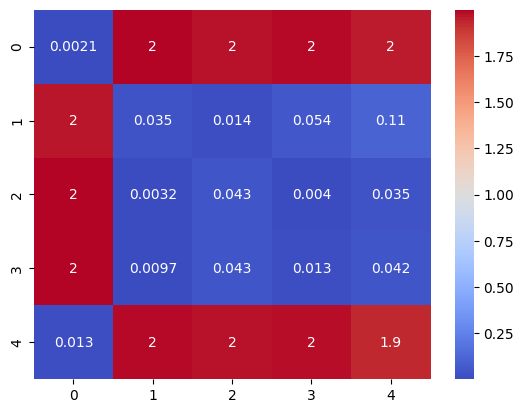

In [49]:
distances = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        distances[i, j] = cosine(center_fig[i], center_libe[j])

sns.heatmap(pd.DataFrame(distances), annot=True, cmap="coolwarm")

<Axes: >

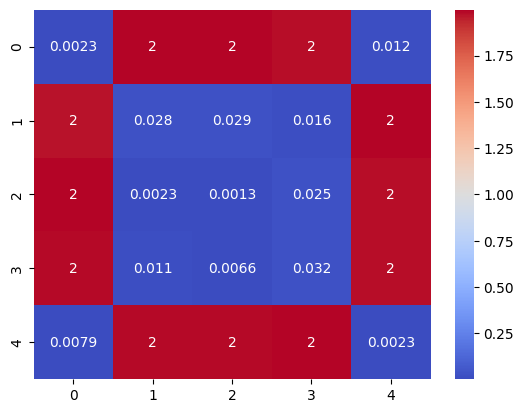

In [43]:
distances = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        distances[i, j] = cosine(center_fig[i], center_monde[j])

sns.heatmap(pd.DataFrame(distances), annot=True, cmap="coolwarm")

In [27]:
cluster_monde

cluster
0    [populisme, souveraineté, justice sociale, lib...
1    [sécurité, economie, défense, police, droits, ...
2                         [société, politique, marché]
3    [démocratie, réforme, identité, droits de l'ho...
4    [écologie, immigration, égalité, santé publiqu...
Name: mot, dtype: object

<Axes: >

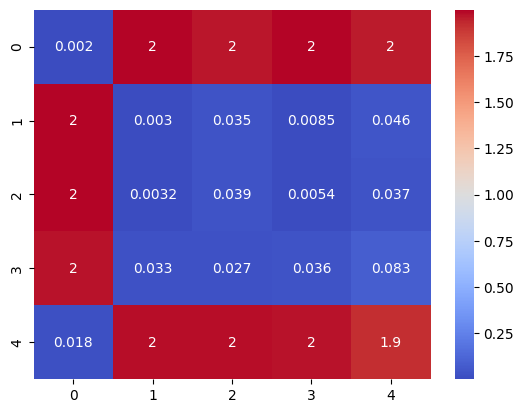

In [50]:
distances = np.zeros((5, 5))

for i in range(5):
    for j in range(5):
        distances[i, j] = cosine(center_monde[i], center_libe[j])

sns.heatmap(pd.DataFrame(distances), annot=True, cmap="coolwarm")

In [29]:
print('cluster total:',cluster_tot)
print('\ncluster monde:',cluster_monde)
print('\ncluster figaro:',cluster_fig)
print('\ncluster liberation:',cluster_libe)

cluster total: cluster
0    [populisme, souveraineté, justice sociale, lib...
1    [sécurité, economie, environnement, défense, a...
2                 [société, politique, marché, droits]
3    [démocratie, réforme, droits de l'homme, admin...
4    [écologie, immigration, égalité, identité, san...
Name: mot, dtype: object

cluster monde: cluster
0    [populisme, souveraineté, justice sociale, lib...
1    [sécurité, economie, défense, police, droits, ...
2                         [société, politique, marché]
3    [démocratie, réforme, identité, droits de l'ho...
4    [écologie, immigration, égalité, santé publiqu...
Name: mot, dtype: object

cluster figaro: cluster
0    [populisme, souveraineté, libéralisme, nationa...
1    [sécurité, environnement, défense, armée, poli...
2       [economie, société, politique, marché, droits]
3    [démocratie, réforme, droits de l'homme, techn...
4    [écologie, immigration, égalité, identité, jus...
Name: mot, dtype: object

cluster liberation: cluster

In [30]:
for i in cluster_tot:
    print(len(i))

50
11
4
12
25


In [31]:
for i in cluster_fig:
    print(len(i))

45
7
5
19
26


In [32]:
for i in cluster_monde:
    print(len(i))

45
8
3
15
31


In [33]:
for i in cluster_libe:
    print(len(i))

68
12
1
2
19


look at correspondance analysis

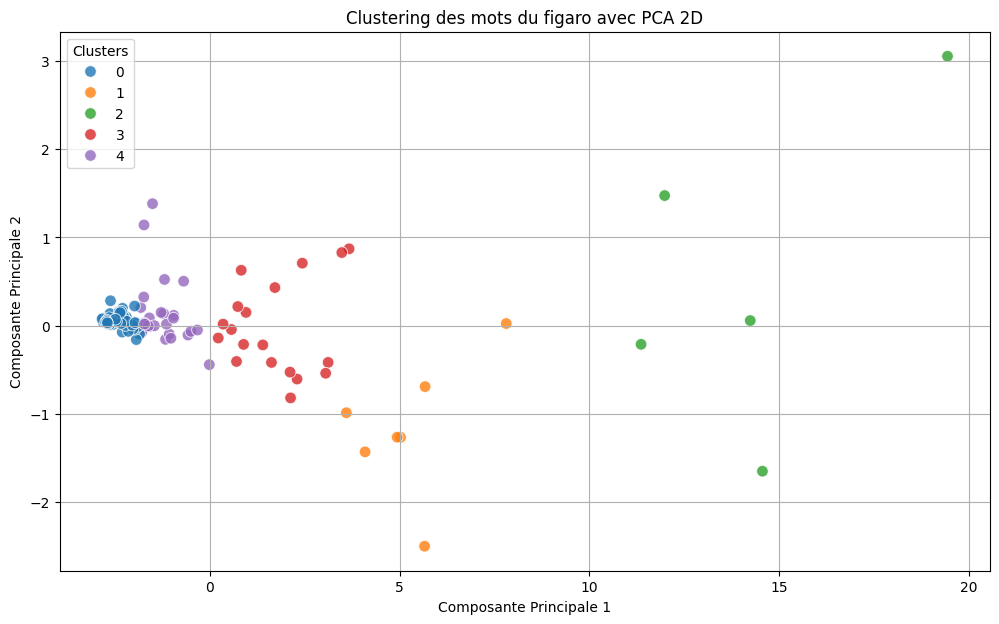

In [34]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(standX_fig)

# Ajout des nouvelles colonnes PCA
df_fig["PC1"] = X_pca[:, 0]
df_fig["PC2"] = X_pca[:, 1]

# Affichage du scatter plot des clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_fig, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70, alpha=0.8)
plt.title("Clustering des mots du figaro avec PCA 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title="Clusters")
plt.grid()
plt.show()

In [39]:
pca.explained_variance_ratio_

array([0.96855605, 0.01354983])

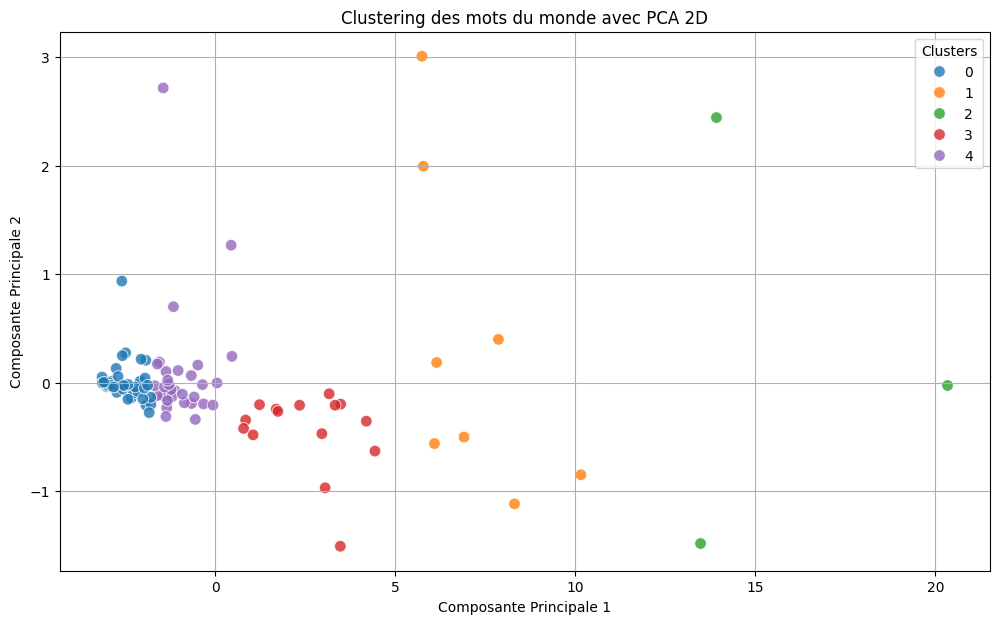

In [35]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(standX_monde)

# Ajout des nouvelles colonnes PCA
df_monde["PC1"] = X_pca[:, 0]
df_monde["PC2"] = X_pca[:, 1]

# Affichage du scatter plot des clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_monde, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70, alpha=0.8)
plt.title("Clustering des mots du monde avec PCA 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title="Clusters")
plt.grid()
plt.show()

In [ ]:
pca.explained_variance_ratio_

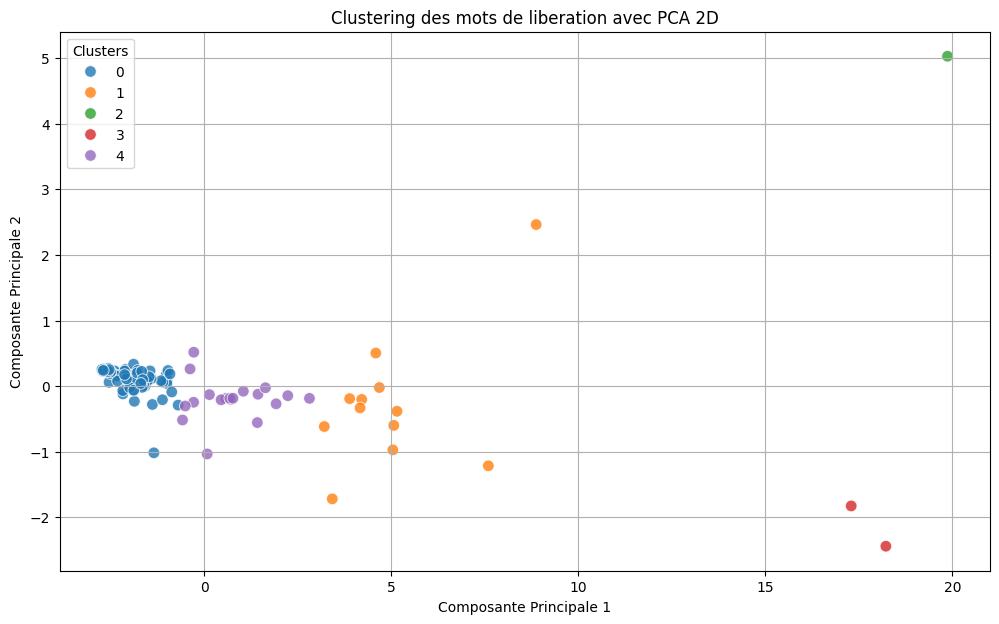

In [40]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(standX_libe)

# Ajout des nouvelles colonnes PCA
df_libe["PC1"] = X_pca[:, 0]
df_libe["PC2"] = X_pca[:, 1]

# Affichage du scatter plot des clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_libe, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70, alpha=0.8)
plt.title("Clustering des mots de liberation avec PCA 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title="Clusters")
plt.grid()
plt.show()

In [41]:
pca.explained_variance_ratio_

array([0.95046785, 0.03054941])

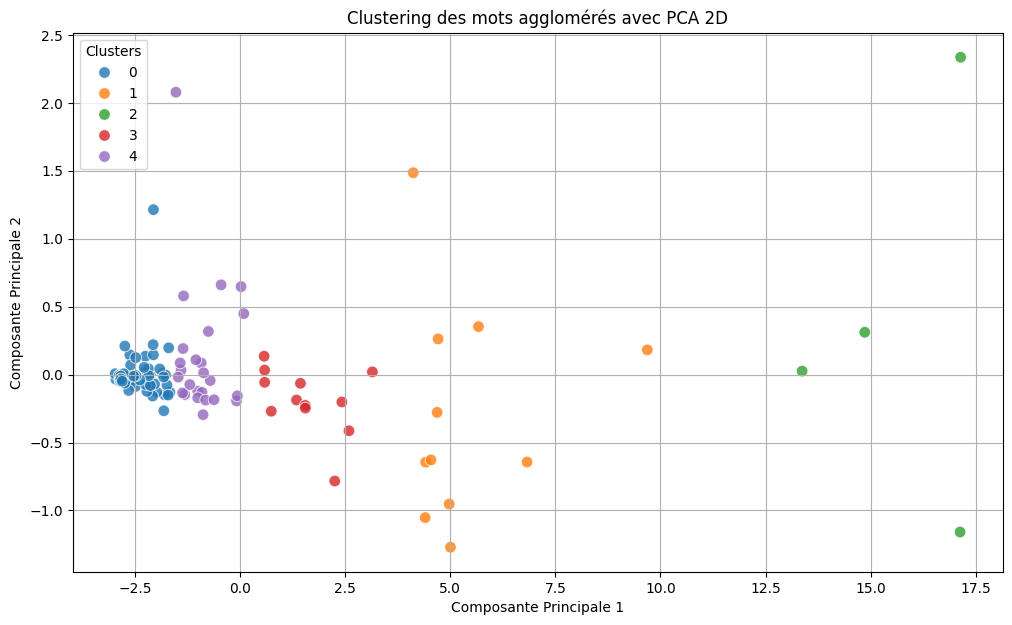

In [37]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(standX_tot)

# Ajout des nouvelles colonnes PCA
df_tot["PC1"] = X_pca[:, 0]
df_tot["PC2"] = X_pca[:, 1]

# Affichage du scatter plot des clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_tot, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70, alpha=0.8)
plt.title("Clustering des mots agglomérés avec PCA 2D")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.legend(title="Clusters")
plt.grid()
plt.show()

In [38]:
clust=[[],[],[],[]]# clust_tot,libe,figaro,monde
clusters=[cluster_tot,cluster_libe,cluster_fig,cluster_monde]
for i in libe.keys():
    

IndentationError: expected an indented block (395077903.py, line 4)

In [ ]:
cluster_tot[0]

['populisme',
 'souveraineté',
 'justice sociale',
 'libéralisme',
 'nationalisme',
 'fédéralisme',
 'diversité',
 'religion',
 'catholique',
 'juif',
 'gouvernance',
 'législation',
 'régulation',
 'transparence',
 'fiscalité',
 'dette publique',
 'capitalisme',
 'socialisme',
 'inégalités',
 'pauvreté',
 'cohésion sociale',
 'exclusion',
 'intégration',
 'changement climatique',
 'développement durable',
 'biodiversité',
 'énergie renouvelable',
 'pollution',
 'cyber sécurité',
 "liberté d'expression",
 'droits civiques',
 'discrimination',
 'égalité des sexes',
 'LGBTQ',
 'assurance maladie',
 'vaccination',
 'prévention',
 'intelligence artificielle',
 'identité culturelle',
 'diversité culturelle',
 'géopolitique',
 'systéme judiciaire',
 'réinsertion',
 'punition',
 'asile',
 'xénophobie',
 'laicité',
 'culte',
 'extrémisme',
 'décentralisation']

In [ ]:
cluster_fig

cluster
0    [populisme, souveraineté, libéralisme, nationa...
1    [sécurité, environnement, défense, armée, poli...
2       [economie, société, politique, marché, droits]
3    [démocratie, réforme, droits de l'homme, techn...
4    [écologie, immigration, égalité, identité, jus...
Name: mot, dtype: object

In [ ]:
adjusted_rand_score(cluster_tot,cluster_tot)

ValueError: You appear to be using a legacy multi-label data representation. Sequence of sequences are no longer supported; use a binary array or sparse matrix instead - the MultiLabelBinarizer transformer can convert to this format.